# 02 · The Dot Product
<sub>Math Foundations Sandbox &nbsp;·&nbsp; a hands-on geometry-for-robotics manual &nbsp;·&nbsp; run every cell top-to-bottom</sub>

---

### Recap & why now
Notebook 01 gave us arrows, length, and direction. The natural next question
about *two* vectors is **"how much do they point the same way?"** The dot
product answers exactly that with a single number, and from it we get angles,
projections, and a test for perpendicularity — all workhorses in robotics.

### Learning objectives
1. Compute the dot product two equivalent ways and see they agree.
2. Extract the **angle** between two vectors.
3. Compute the **projection** of one vector onto another.
4. Use the sign of the dot product as an instant *same-way / opposite-way* test.
5. Animate a projection as one vector rotates.


In [1]:
# === Standard setup used throughout this notebook ========================
import numpy as np                 # NumPy = fast vector/matrix math, so we never hand-write loops for arithmetic.
import matplotlib.pyplot as plt     # Matplotlib is our plotting engine for every static figure below.
from matplotlib import animation   # Turns a list of frames into a playable movie (used for the animations).
from IPython.display import HTML    # Embeds an animation as a self-contained JS player (no ffmpeg required).

%matplotlib inline
# Render animations as an in-browser JavaScript player so they always play, on any machine.
plt.rcParams["animation.html"] = "jshtml"
# Raise the embed size cap (MB) so longer clips are not silently cut off.
plt.rcParams["animation.embed_limit"] = 60
# One consistent, readable look for every figure in the manual.
plt.rcParams.update({"figure.dpi": 80, "font.size": 11, "axes.grid": True})
# Print matrices with 3 decimals and no scientific notation, so output is easy to eyeball.
np.set_printoptions(precision=3, suppress=True)
print("Setup complete — NumPy", np.__version__, "| Matplotlib", plt.matplotlib.__version__)

Setup complete — NumPy 2.4.4 | Matplotlib 3.10.8


In [2]:
def draw_vector(ax, tip, tail=(0.0, 0.0), color="C0", label=None, lw=2.2):
    """Draw a 2-D vector as an arrow from `tail` to `tip`.

    Why an annotation and not ax.plot? `annotate` with arrowprops gives us a
    real arrowhead whose size stays fixed in screen space, so the arrow looks
    right no matter how the axes are zoomed.
    """
    tail = np.asarray(tail, float)                 # Accept plain tuples/lists but work in float arrays internally.
    tip  = np.asarray(tip,  float)
    ax.annotate("", xy=tip, xytext=tail,           # Empty text: we only want the arrow, not a caption here.
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw,
                                shrinkA=0, shrinkB=0))  # shrink=0 so the arrow touches the exact endpoints.
    if label:                                      # Optionally print the vector's name near its midpoint.
        mid = tail + 0.5 * (tip - tail)            # Midpoint of the arrow, a natural spot for the label.
        ax.text(mid[0], mid[1], "  " + label, color=color,
                fontsize=12, ha="left", va="bottom")

def square_axes(ax, lim):
    """Force equal aspect + symmetric limits.

    Why: rotations and angles only *look* correct when one unit on x equals one
    unit on y. Without equal aspect a circle would render as an ellipse and a
    90-degree turn would look like something else.
    """
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim) # Symmetric window centred on the origin.
    ax.set_aspect("equal", adjustable="box")       # 1 unit in x == 1 unit in y on screen.
    ax.axhline(0, color="0.7", lw=1); ax.axvline(0, color="0.7", lw=1)  # Faint axes through the origin.

## 1 · Two formulas, one number

The dot product has an **algebraic** form and a **geometric** form:

$$\mathbf{a}\cdot\mathbf{b} \;=\; a_x b_x + a_y b_y \;=\; \lVert\mathbf{a}\rVert\,\lVert\mathbf{b}\rVert\cos\theta.$$

The algebraic form is what a computer evaluates; the geometric form is what it
*means* (length × length × alignment). Because they are equal, we can solve the
geometric one for $\theta$ — that's the next section.


In [3]:
a = np.array([3.0, 1.0])          # First vector.
b = np.array([1.0, 2.0])          # Second vector.

dot_manual = a[0]*b[0] + a[1]*b[1]   # Algebraic form written out, to show there is no magic.
dot_numpy  = np.dot(a, b)            # The same thing via NumPy (also spelled a @ b) — fast and general.
print("a·b (by hand) =", dot_manual)
print("a·b (np.dot)  =", dot_numpy)
print("a @ b         =", a @ b, " (the @ operator is matrix/inner product)")

# Now confirm the GEOMETRIC form gives the identical number.
geo = np.linalg.norm(a) * np.linalg.norm(b) * np.cos(
        np.arccos(np.dot(a, b)/(np.linalg.norm(a)*np.linalg.norm(b))))  # ||a||·||b||·cosθ, with θ recovered from the vectors.
print("||a||||b||cosθ =", geo, " (matches, as it must)")


a·b (by hand) = 5.0
a·b (np.dot)  = 5.0
a @ b         = 5.0  (the @ operator is matrix/inner product)
||a||||b||cosθ = 5.0  (matches, as it must)


## 2 · The angle between two vectors

Rearrange the geometric form:
$\displaystyle \cos\theta = \frac{\mathbf{a}\cdot\mathbf{b}}{\lVert\mathbf{a}\rVert\,\lVert\mathbf{b}\rVert}$,
so $\theta = \arccos(\cdot)$. One numerical caution: floating-point round-off can
push that ratio a hair outside $[-1,1]$, which would make `arccos` return `nan`.
We **clip** to be safe — a habit worth forming.


angle([1,0],[0,1]) = 90.0 deg  (perpendicular -> 90)
angle([1,0],[1,1]) = 45.00000000000001 deg  (45)
angle([1,0],[-1,0])= 180.0 deg  (opposite -> 180)


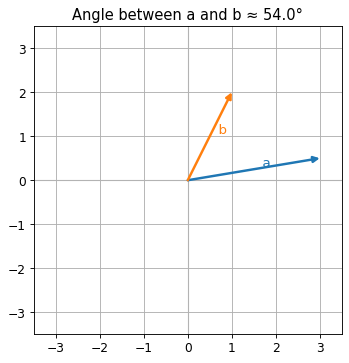

In [4]:
def angle_between(a, b, degrees=True):
    """Angle between two vectors, robust to floating-point round-off."""
    a = np.asarray(a, float); b = np.asarray(b, float)
    cos_t = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))  # cosθ from the dot-product identity.
    cos_t = np.clip(cos_t, -1.0, 1.0)     # Clip into [-1,1] so tiny round-off never yields nan from arccos.
    theta = np.arccos(cos_t)              # Invert cosine to get the angle in radians.
    return np.degrees(theta) if degrees else theta   # Report in degrees by default — easier to sanity-check.

print("angle([1,0],[0,1]) =", angle_between([1,0], [0,1]), "deg  (perpendicular -> 90)")
print("angle([1,0],[1,1]) =", angle_between([1,0], [1,1]), "deg  (45)")
print("angle([1,0],[-1,0])=", angle_between([1,0], [-1,0]), "deg  (opposite -> 180)")

# Visualise one case so the number has a picture attached.
a = np.array([3.0, 0.5]); b = np.array([1.0, 2.0])
fig, ax = plt.subplots(figsize=(5, 5))
draw_vector(ax, a, color="C0", label="a")
draw_vector(ax, b, color="C1", label="b")
square_axes(ax, 3.5)
ax.set_title(f"Angle between a and b ≈ {angle_between(a,b):.1f}°")
plt.show()


## 3 · Projection: how much of **a** lies along **b**

The **scalar projection** of $\mathbf{a}$ onto $\mathbf{b}$ is
$\dfrac{\mathbf{a}\cdot\mathbf{b}}{\lVert\mathbf{b}\rVert}$ — the length of
$\mathbf{a}$'s shadow on the line of $\mathbf{b}$. Multiply by the *unit* vector
of $\mathbf{b}$ to get the **vector projection**: the actual shadow arrow. This
is how you split any vector into "along this direction" and "perpendicular to
it" — the core trick behind decomposing forces and velocities.


scalar projection = 3.0
vector projection = [3. 0.]
perp·b (≈0?)      = 0.0


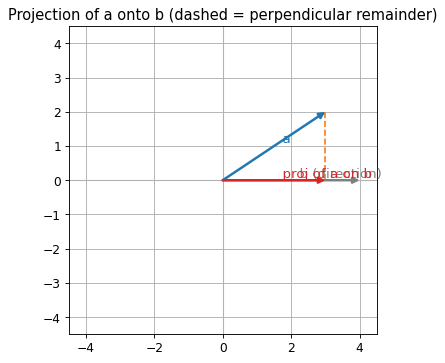

In [5]:
a = np.array([3.0, 2.0])            # The vector we want to split.
b = np.array([4.0, 0.0])            # The direction we project onto (here, the x-axis for clarity).

b_hat      = b / np.linalg.norm(b)                 # Unit vector of b: the pure direction of the "shadow line".
scalar_proj = np.dot(a, b_hat)                     # a·b_hat = signed length of a's shadow on b.
vector_proj = scalar_proj * b_hat                  # Re-attach the direction to get the shadow AS a vector.
perp        = a - vector_proj                      # What's left is exactly perpendicular to b (a = proj + perp).
print("scalar projection =", scalar_proj)
print("vector projection =", vector_proj)
print("perp·b (≈0?)      =", np.dot(perp, b))      # Near zero confirms the leftover is perpendicular to b.

fig, ax = plt.subplots(figsize=(5.5, 5))
draw_vector(ax, a,           color="C0", label="a")
draw_vector(ax, b,           color="0.5", label="b (direction)")
draw_vector(ax, vector_proj, color="C3", label="proj of a on b")
ax.plot([a[0], vector_proj[0]], [a[1], vector_proj[1]], "--", color="C1")  # Dashed drop-line = the perpendicular piece.
square_axes(ax, 4.5)
ax.set_title("Projection of a onto b (dashed = perpendicular remainder)")
plt.show()


## 4 · The sign of the dot product is a free alignment test

Because $\mathbf{a}\cdot\mathbf{b} = \lVert\mathbf{a}\rVert\lVert\mathbf{b}\rVert\cos\theta$
and the lengths are positive, the **sign** is the sign of $\cos\theta$:

| dot product | angle | meaning |
|---|---|---|
| $>0$ | $<90^\circ$ | pointing broadly the *same* way |
| $=0$ | $=90^\circ$ | **perpendicular** |
| $<0$ | $>90^\circ$ | pointing broadly the *opposite* way |

No `arccos`, no square roots — one multiply-add tells a robot whether it is
moving *toward* or *away from* a goal.


In [6]:
goal_dir = np.array([1.0, 1.0])                       # The direction we WANT to head (e.g. toward a waypoint).
for name, motion in [("moving toward",  [2.0, 1.0]),  # Roughly aligned with the goal.
                     ("sideways",       [1.0, -1.0]), # Exactly perpendicular to the goal.
                     ("moving away",    [-1.0, -2.0])]:# Roughly opposite the goal.
    d = np.dot(goal_dir, np.array(motion))            # One dot product decides the verdict.
    verdict = "toward (+)" if d > 1e-9 else ("perpendicular (0)" if abs(d) <= 1e-9 else "away (-)")
    print(f"{name:14s}: dot = {d:+.1f}  ->  {verdict}")


moving toward : dot = +3.0  ->  toward (+)
sideways      : dot = +0.0  ->  perpendicular (0)
moving away   : dot = -3.0  ->  away (-)


## 🧪 Try it yourself

**E1.** For `p = [2, 5]` and `q = [6, 1]`, compute the angle between them and the
vector projection of `p` onto `q`. Verify that `p − proj` is perpendicular to `q`
(its dot product with `q` should be ~0).

**E2.** Write `is_orthogonal(a, b, tol=1e-9)` returning `True` when two vectors
are perpendicular. Test it on `[1, 0]/[0, 1]` (True) and `[1, 1]/[1, 2]` (False).


In [7]:
# --- Solution E1 -------------------------------------------------------------
p = np.array([2.0, 5.0]); q = np.array([6.0, 1.0])
def angle_between(a, b):                                  # (Re-defined locally so this cell is self-contained.)
    c = np.clip(np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b)), -1, 1)
    return np.degrees(np.arccos(c))
q_hat = q/np.linalg.norm(q)                               # Direction of q.
proj  = np.dot(p, q_hat)*q_hat                            # Vector projection of p onto q.
print("angle(p,q)     =", angle_between(p, q), "deg")
print("proj of p on q =", proj)
print("(p-proj)·q     =", np.dot(p-proj, q), " (≈0 ⇒ perpendicular)")

# --- Solution E2 -------------------------------------------------------------
def is_orthogonal(a, b, tol=1e-9):
    # Perpendicular <=> dot product is (numerically) zero. We compare against a
    # small tolerance rather than exact 0 because floats rarely land on exact 0.
    return abs(np.dot(a, b)) <= tol
print("orthogonal([1,0],[0,1]) =", is_orthogonal([1,0], [0,1]))
print("orthogonal([1,1],[1,2]) =", is_orthogonal([1,1], [1,2]))


angle(p,q)     = 58.736268305622566 deg
proj of p on q = [2.757 0.459]
(p-proj)·q     = -1.7763568394002505e-15  (≈0 ⇒ perpendicular)
orthogonal([1,0],[0,1]) = True
orthogonal([1,1],[1,2]) = False


## 🚁 Mini-project: a rotating vector and its shadow

We rotate a vector $\mathbf{a}$ steadily and animate its **projection** onto a
fixed direction $\mathbf{b}$. Watch the shadow grow, shrink, vanish (at $90^\circ$),
and reverse sign. This is the geometric heartbeat behind sensor readings that
depend on *alignment* — like how much sunlight hits a tilted solar panel, or how
much of a drone's thrust fights gravity.


In [8]:
b = np.array([1.0, 0.0])                     # Fixed reference direction (the x-axis, for an easy-to-read shadow).
b_hat = b / np.linalg.norm(b)                # Its unit vector (used to build the projection each frame).
n_frames = 60                               # Enough frames for one smooth full rotation.
spin = np.linspace(0, 2*np.pi, n_frames)     # The rotating vector's angle, swept over a full turn.

fig, ax = plt.subplots(figsize=(5.4, 5))
square_axes(ax, 2.2)
ax.plot([-2.2, 2.2], [0, 0], color="0.5", lw=1)          # Draw the projection line (direction of b) once.
(arrow_a,) = ax.plot([], [], color="C0", lw=2.5)          # The rotating vector a (drawn as a line for easy updating).
(arrow_p,) = ax.plot([], [], color="C3", lw=4)            # Its shadow (vector projection) on b.
(drop,)    = ax.plot([], [], "--", color="C1", lw=1)      # The perpendicular drop-line from a's tip to the line.
title = ax.set_title("")

def update(i):
    a = 1.8*np.array([np.cos(spin[i]), np.sin(spin[i])])  # A length-1.8 vector pointing at the current angle.
    proj = np.dot(a, b_hat) * b_hat                       # Its vector projection onto b (the shadow).
    arrow_a.set_data([0, a[0]], [0, a[1]])                # Redraw a from origin to its tip.
    arrow_p.set_data([0, proj[0]], [0, proj[1]])          # Redraw the shadow from origin to proj.
    drop.set_data([a[0], proj[0]], [a[1], proj[1]])       # The dashed perpendicular from a's tip down to the line.
    title.set_text(f"projection length = {np.dot(a, b_hat):+.2f}")  # Live signed shadow length.
    return arrow_a, arrow_p, drop, title

anim = animation.FuncAnimation(fig, update, frames=n_frames, interval=40, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())


> **🤖 Robotics connection.** The dot product is the robot's alignment sensor. A
positive value with the goal direction means *making progress*; zero means
*moving sideways*; negative means *going the wrong way*. Projection decomposes a
velocity into "toward the target" and "off to the side", which is the first step
in steering laws. Next we meet the dot product's 3-D partner, the **cross
product**, which produces a *perpendicular* vector and measures **turning** —
essential for torque and for a drone's angular motion.